In [177]:
#imported necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import r2_score



In [179]:
#load data sets 
data = pd.read_csv("data.csv")

education = pd.read_csv("education_data.csv")

data_details = pd.read_csv("data-details.csv")



In [180]:
#merge education data with main dataset using unique_id
df = pd.merge(data, education, on='unique_id', how='left')

In [181]:
#display the new data frame 
df.head()

,unique_id,birth_year,workclass,fnlwgt,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,education,education-num
0,b788ecae-24d3-4d2f-be70-291c656cfe35,2006,?,137363,Never-married,?,Own-child,White,Female,0,0,30,United-States,139650,Some-college,10.0
1,c50f5eec-eee7-4f71-92ad-5fd2baace470,1989,Private,188041,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,80122,Some-college,10.0
2,42dbe1ab-593f-4d41-b72f-32bb2081c64c,1999,Private,178478,Never-married,Adm-clerical,Own-child,White,Female,0,0,40,United-States,115722,Bachelors,13.0
3,008c8da5-1688-4b85-a0d0-0516405c84d0,1981,Private,177905,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,3908,0,40,United-States,97534,HS-grad,9.0
4,32084da0-d75e-4f29-8c86-b7d120cdb759,1988,?,389850,Married-spouse-absent,?,Unmarried,Black,Male,0,0,50,United-States,113779,HS-grad,9.0


In [182]:
# Replace placeholder '?' with actual missing value indicator (NaN)
df.replace(['?', ''], np.nan, inplace=True)


In [183]:
# Create 'age' from 'birth_year' and drop 'birth_year'
CURRENT_YEAR = 2025
df['age'] = 2025 - df['birth_year']
df.drop(['birth_year', 'fnlwgt', 'unique_id'], axis=1, inplace=True)

In [184]:
# Convert 'income' column to numeric (in case it's read as string)
df['income'] = pd.to_numeric(df['income'], errors='coerce')


In [185]:
# Define numerical columns to clean
numerical_cols = ['birth_year', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']


In [186]:
# Convert and fill missing numerical values with median
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_139/245460615.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [187]:
#Define categorical columns to clean
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [188]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()  # clean text
    df[col].fillna(df[col].mode()[0], inplace=True)



/tmp/ipykernel_139/2505606352.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [189]:
#check missing values and verify cleaned work
print(df.isna().sum())

workclass         0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
education         0
education-num     0
age               0
dtype: int64


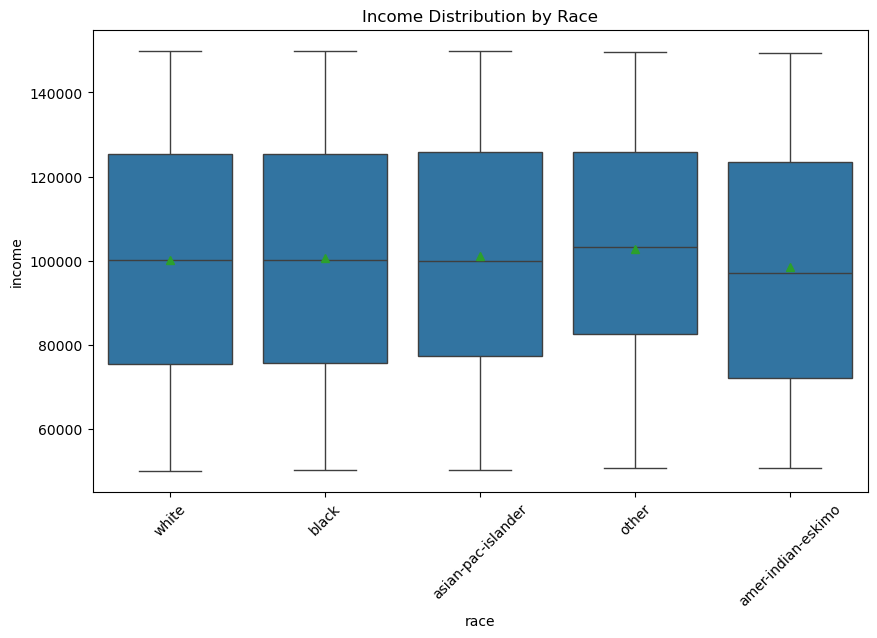

In [208]:
#Racial Disparaties 
plt.figure(figsize=(10, 6))

sns.boxplot(x='race', y='income', data=df, showmeans=True)

plt.title('Income Distribution by Race')
plt.xticks(rotation=45)
plt.show()

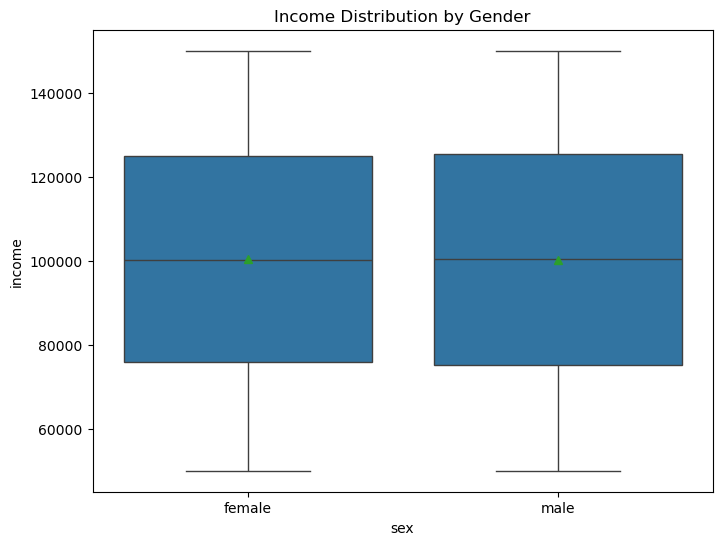

In [191]:
#Gender pay Gap 
plt.figure(figsize=(8, 6)) 

sns.boxplot(x='sex', y='income', data=df, showmeans=True)
plt.title('Income Distribution by Gender') 
plt.show()

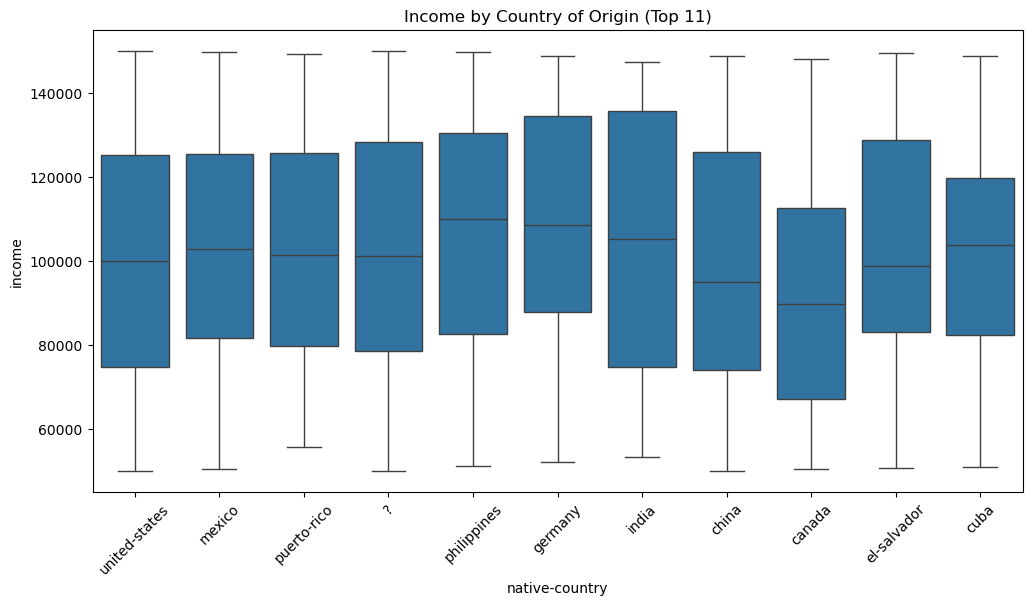

In [192]:
#country of origin
top_countries = df['native-country'].value_counts().nlargest(11).index

df_country = df[df['native-country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='native-country', y='income', data=df_country)

plt.title('Income by Country of Origin (Top 11)')
plt.xticks(rotation=45)
plt.show()

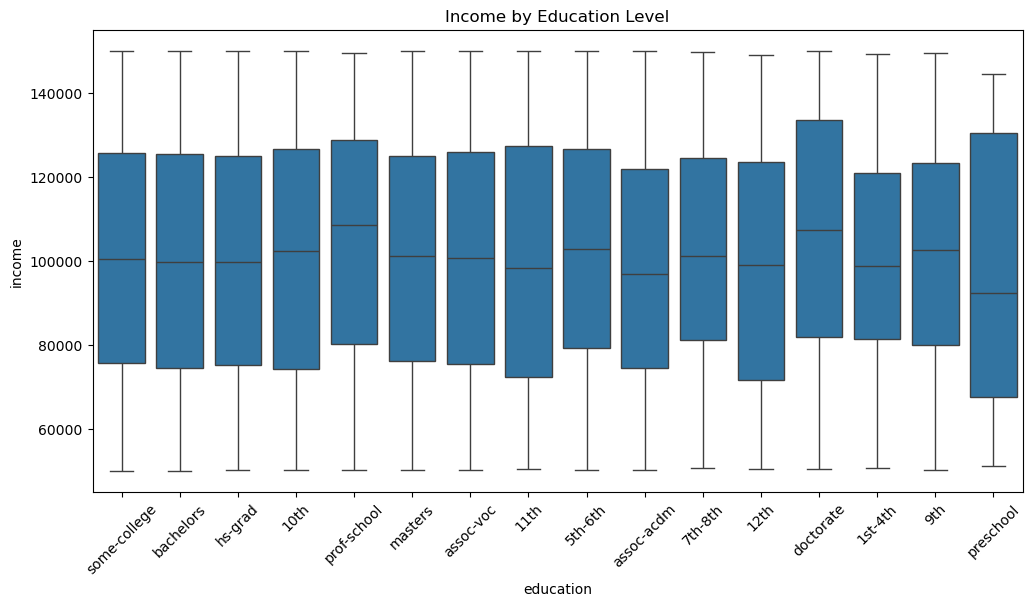

In [193]:
#education vs income
plt.figure(figsize=(12, 6)) 
sns.boxplot(x='education', y='income', data=df) 
plt.title('Income by Education Level') 
plt.xticks(rotation=45) 
plt.show()

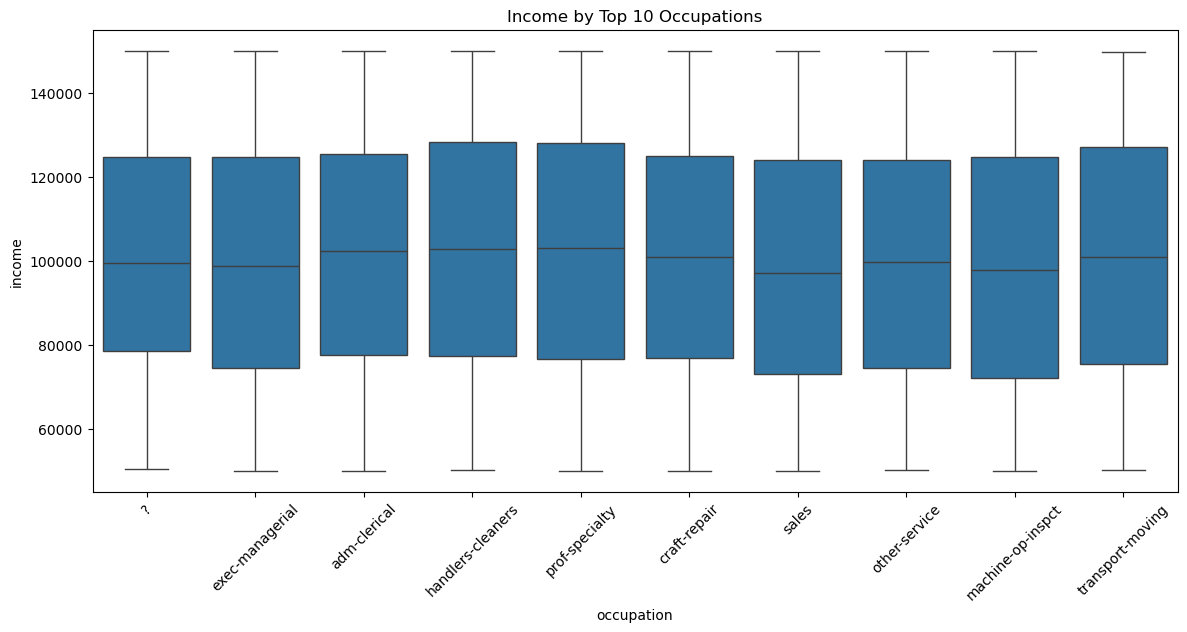

In [194]:
#occupation based pay 
top_occupations = df['occupation'].value_counts().nlargest(10).index

df_occ = df[df['occupation'].isin(top_occupations)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='occupation', y='income', data=df_occ)

plt.title('Income by Top 10 Occupations')
plt.xticks(rotation=45)
plt.show()

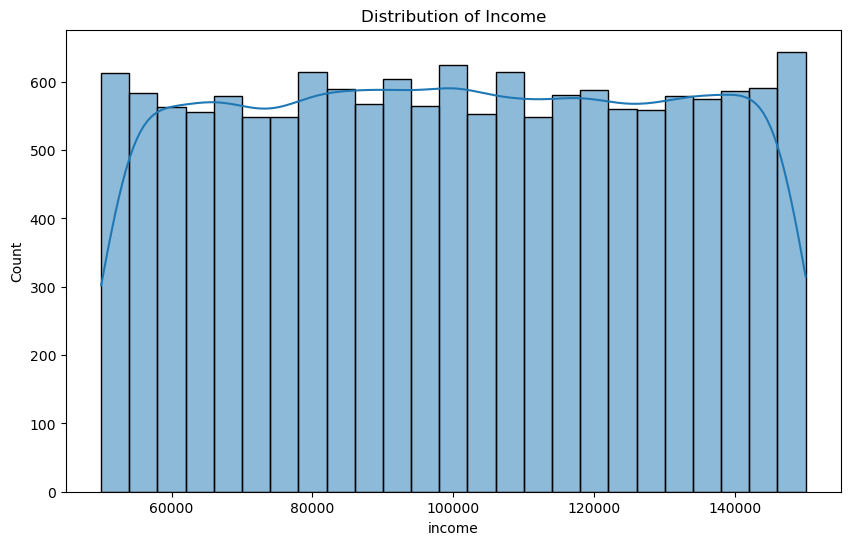

In [195]:
# Visualizing the distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(df['income'], kde=True)
plt.title('Distribution of Income')
plt.show()

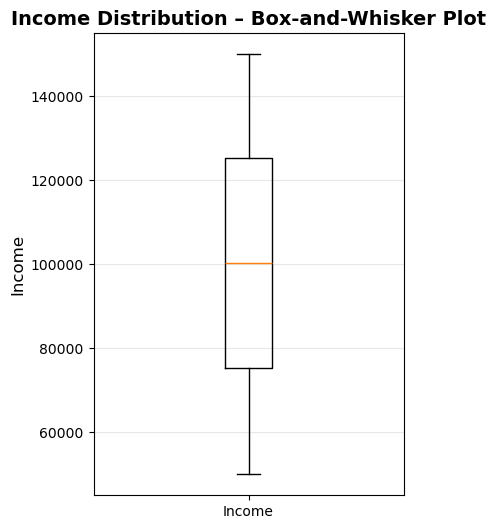

In [196]:
#show outliers of income
plt.figure(figsize=(4,6))
plt.boxplot(df['income'], vert=True)
plt.title('Income Distribution – Box-and-Whisker Plot', fontsize=14, fontweight='bold')
plt.ylabel('Income', fontsize=12)
plt.xticks([1], ['Income'])
plt.grid(axis='y', alpha=0.3)
plt.show()





Preparing the data for modeling 


In [197]:
X = df.drop(columns=['income'])
y = df['income']

# encoding categoprical variables 
X = pd.get_dummies(X, drop_first=True)

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Creating and training the Random Forest model
model = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)



Random Forest Model Results

In [206]:
# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print results with 2 decimal places
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.2f}")

Mean Absolute Error: 26404.65
Mean Squared Error: 961025055.54
Root Mean Squared Error: 31000.40
R² Score: -0.12
